In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:

# Load  dataset
combined_df = pd.read_csv("../training-testing-data/transfer_dataset.csv")

#  training data (2020-2023) for eda as do not want to analyse the testing data so we prevent data leakage
training_seasons = [2020, 2021, 2022, 2023]
train_df = combined_df[combined_df['season'].isin(training_seasons)].copy()

print(f"Total transfers: {len(combined_df)}")
print(f"Training data transfers for EDA: {len(train_df)}")


Total transfers: 2020
Training data transfers for EDA: 1562


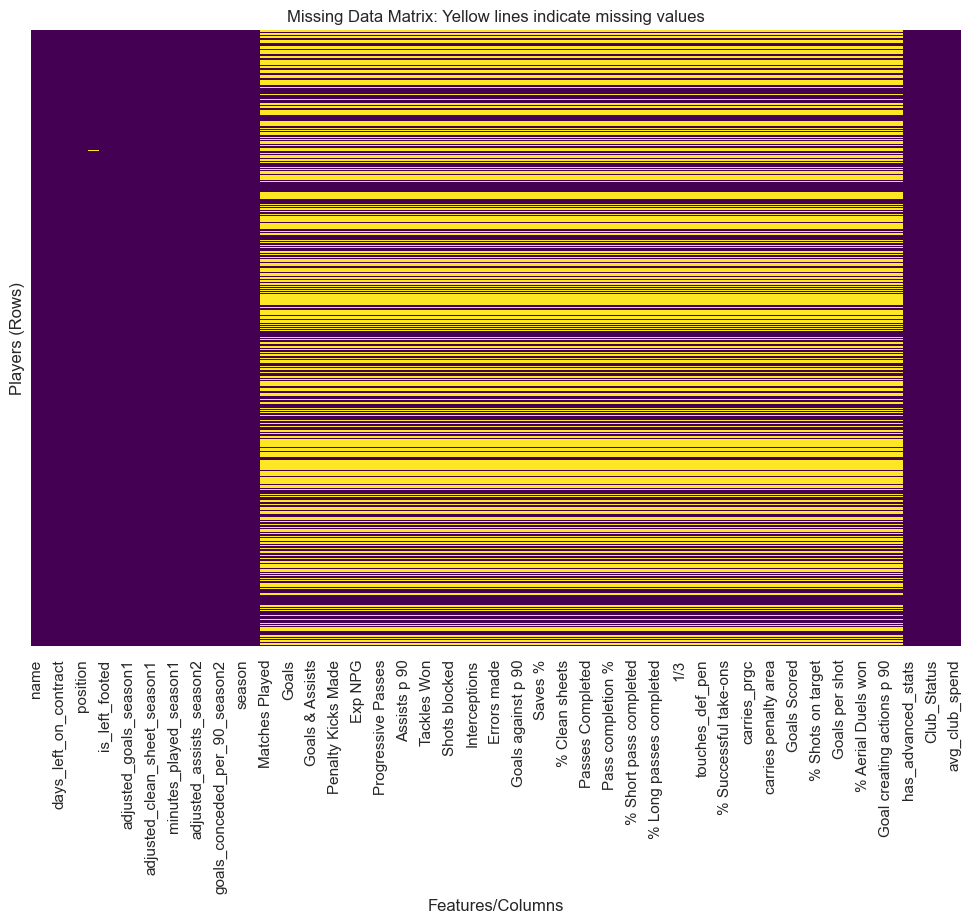

Percentage of missing advanced stats: 56.08%


In [38]:


plt.figure(figsize=(12, 8))
# train_df.isnull() creates a True/False matrix. True (missing) will be plotted as yellow.
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Missing Data Matrix: Yellow lines indicate missing values')
plt.xlabel('Features/Columns')
plt.ylabel('Players (Rows)')
plt.show()

# print the percentage of players with missing advanced stats
pct_missing_xg = train_df['has_advanced_stats']==0
lol=pct_missing_xg.mean() * 100
print(f"Percentage of missing advanced stats: {lol:.2f}%")

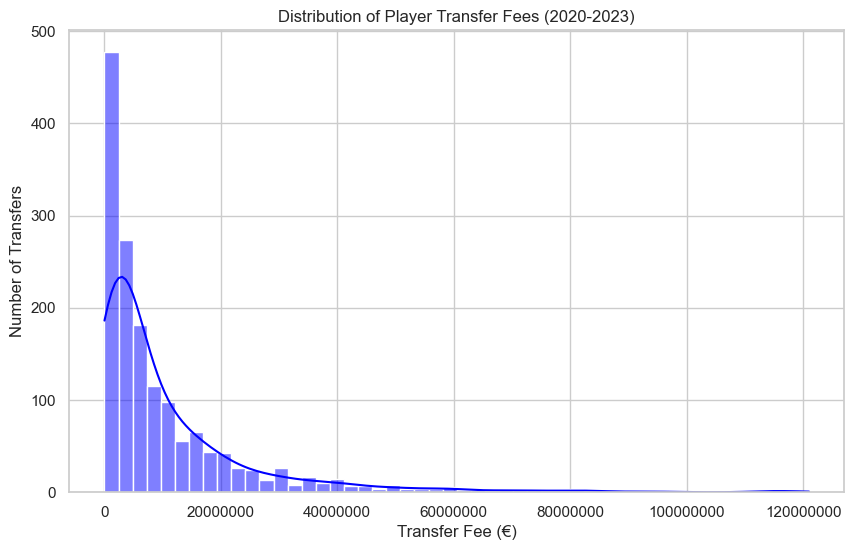

In [ ]:


# background style
sns.set_theme(style="whitegrid")

#  size of the image
plt.figure(figsize=(10, 6))

#Create histogram
# data = training data
# x = our target which is transfer value 
# bins = how many buckets to divide the data into 
# kde = True adds a curve to show the geenral shape of the graph
sns.histplot(data=train_df, x='transfer_fee', bins=50, kde=True, color='blue')

#add titles 
plt.title('Distribution of Player Transfer Fees (2020-2023)')
plt.xlabel('Transfer Fee (€)')
plt.ylabel('Number of Transfers')

# prevents using natural numbers e.g e for  big numbers
plt.ticklabel_format(style='plain', agevfeeis='x')

# show graph
plt.show()

In [ ]:


# background style
sns.set_theme(style="whitegrid")

#  size of the image
plt.figure(figsize=(10, 6))

#Create histogram
# data = training data
# x = our target which is transfer value 
# bins = how many buckets to divide the data into 
# kde = True adds a curve to show the geenral shape of the graph
sns.histplot(data=train_df, x='transfer_fee', bins=50, kde=True, color='blue')

#add titles 
plt.title('Distribution of Player Transfer Fees (2020-2023)')
plt.xlabel('Transfer Fee (€)')
plt.ylabel('Number of Transfers')

# prevents using natural numbers e.g e for  big numbers
plt.ticklabel_format(style='plain', agevfeeis='x')

# show graph
plt.show()

C:\Users\44757\AppData\Local\Temp\ipykernel_8128\2117150091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=position_counts.index, y=position_counts.values, palette='viridis')


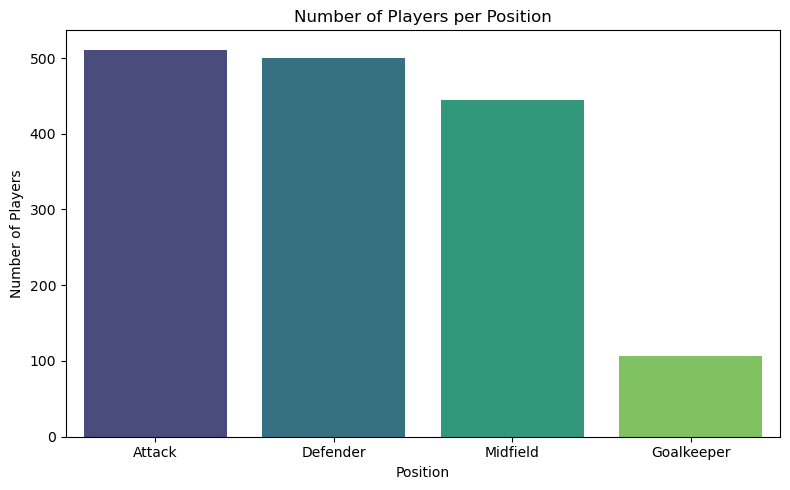

In [6]:
#plot the number of players per position in the dataset 
plt.figure(figsize=(8, 5))
position_counts = train_df['position'].value_counts()
sns.barplot(x=position_counts.index, y=position_counts.values, palette='viridis')
plt.title('Number of Players per Position')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

In [39]:
# Split training data into Outfield Players and Goalkeepers due heavy imbalance of data 
# and is clear that different features will be important
gk_train_df = train_df[train_df['position'] == 'Goalkeeper']
outfield_train_df = train_df[train_df['position'] != 'Goalkeeper']

# Select only numeric columns as cannot calculate correlations for non numeric data
goalkeeper_numeric_df = gk_train_df.select_dtypes(include=[np.number])
outfield_numeric_df = outfield_train_df.select_dtypes(include=[np.number])

#what we are trying to predict 
target = 'transfer_fee'

#total number of outfield players and goalkeepers in the dataset
print(f"Outfield Players: {len(outfield_numeric_df)}")
print(f"Goalkeepers: {len(goalkeeper_numeric_df)}")

Outfield Players: 1455
Goalkeepers: 107


The 90th percentile for Average Club Spend is: €20,812,498


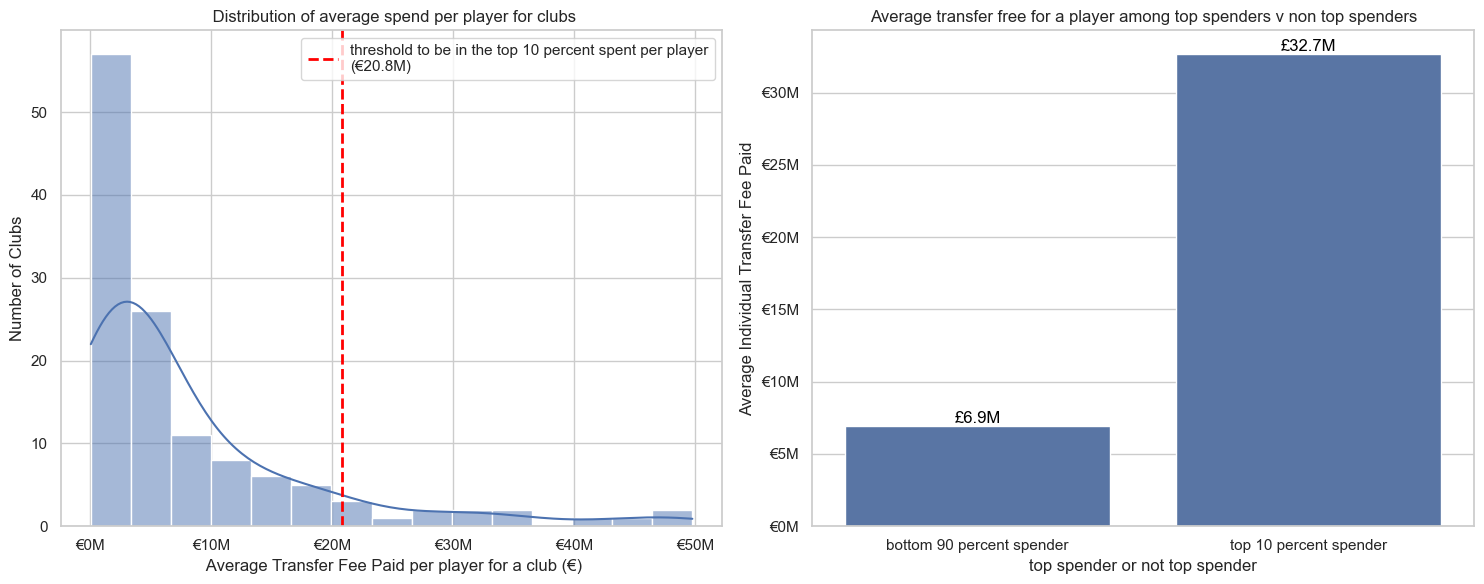

In [ ]:

# Group the data by clubs transferred to and then calculate the mean to give the average price each club pays for a player.
# Save this result to a new table called average_spend. 
# If we do not reset index, then the to_club_name feature that I grouped by would become the new index of the data.
average_spend = train_df.groupby('to_club_name')['transfer_fee'].mean().reset_index()

# Rename the transfer_fee column to avg_club_spend in the table as it now represents this. 
average_spend.rename(columns={'transfer_fee': 'avg_club_spend'}, inplace=True)

# Find the amount of money that clubs need to spend on average for a player to be in the top 10 percent of highest spending clubs per player.
threshold_top_spender = average_spend['avg_club_spend'].quantile(0.90)

print(f"The 90th percentile for Average Club Spend is: €{threshold_top_spender:,.0f}")


#jupyter notebooks have a memeory so if these columns already exist when the code is run drop them to avoid merge errors an dthe code crashing
if 'avg_club_spend' in train_df.columns:
    train_df.drop(columns=['avg_club_spend'], inplace=True)
if 'Club_Status' in train_df.columns:
    train_df.drop(columns=['Club_Status'], inplace=True)

# Left join the average spend per club onto the original dataframe based on club name. 
train_df = train_df.merge(average_spend, on='to_club_name', how='left')

# Create a new column called Club_Status and state whether the club is a top spender or not.
train_df['Club_Status'] = train_df['avg_club_spend'].apply(
    lambda x: 'top 10 percent spender' if x >= threshold_top_spender else 'bottom 90 percent spender'
)








# Set style

sns.set_theme(style="whitegrid")
#fig is the overall large canvas figsize sets the size of it
#agevfeees are the slots on the canvas agevfeees[0] is the first agevfeees[1] the second 1,2 defines the slots for any graphs one row and 2 columns so the graphs will be side to side


fig, agevfeees = plt.subplots(1, 2, figsize=(15, 6))



#histogram showing the number of teams above and below the threshold
# data is what is used to plot the histogram in this case  the average spend data
#bins are intervals of the histogram have set this to be decided automatically
##kde draws a line to show the shape of the data
# agevfee is the agevfeees where the graoh is draen have set this to the first column (left) of the grid 

sns.histplot(data=average_spend['avg_club_spend'], bins='auto', kde=True, agevfee=agevfeees[0])

# draws a line on the first graph at the point on the x agevfeeis where the thereshold is 
#dashed line with a thickness of 2
#number is formatted in millions my dividing by 1 million (/1e6) and rounded to 1dp (1f)
agevfeees[0].agevfeevline(threshold_top_spender, color='red', linestyle='--', linewidth=2, label=f'threshold to be in the top 10 percent spent per player\n(€{threshold_top_spender/1e6:.1f}M)')

agevfeees[0].set_title(' Distribution of average spend per player for clubs')

agevfeees[0].set_xlabel(' Average Transfer Fee Paid per player for a club (€)')

agevfeees[0].set_ylabel('Number of Clubs')

#draw the label
agevfeees[0].legend()
#formats the x agevfeeis in the same way as earlier in millions
agevfeees[0].xagevfeeis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x/1e6:,.0f}M'))

#PLOT 2

#bar chart data is the training data frame speciy categories from the dataframe that should go along the x and y agevfeeis 
#and that the graph should be in the second clumn in the  grid 
# and now error intervals on top of bars
sns.barplot(data=train_df, x='Club_Status', y='transfer_fee', agevfee=agevfeees[1], errorbar=None)
agevfeees[1].set_title('Average transfer free for a player among top spenders v non top spenders')
agevfeees[1].set_xlabel('top spender or not top spender')
agevfeees[1].set_ylabel('Average Individual Transfer Fee Paid')
agevfeees[1].yagevfeeis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x/1e6:,.0f}M'))

#loop throgh every bar on the second graph
for bar in agevfeees[1].patches:
    #write the height of each bar which would be the average spend per player and divide by one million to format nicer
    agevfeees[1].annotate(f'£{bar.get_height()/1e6:,.1f}M',
                     #specifies where to write the text and dont size and color 
                (bar.get_x() + bar.get_width() / 2., bar.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black')

#autoformats the graph incase text is overlapping or getting cutoff
plt.tight_layout()
plt.show()


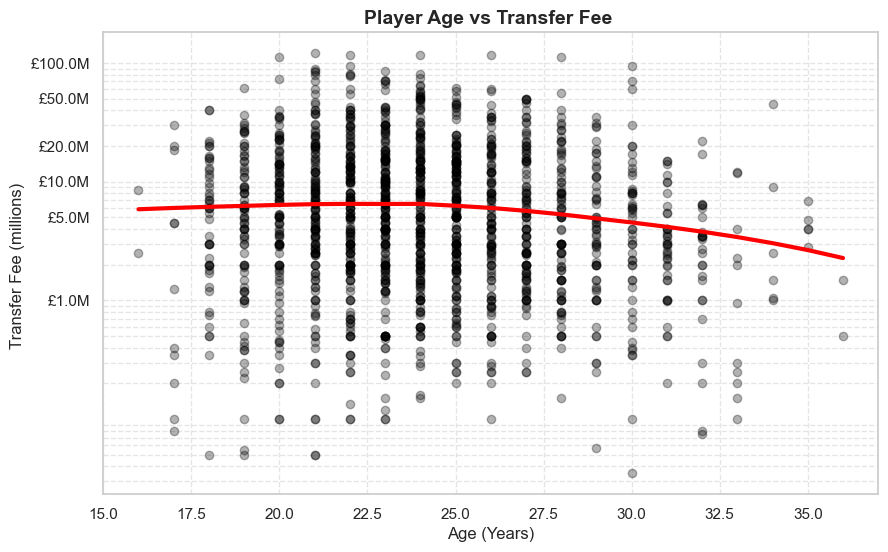

In [84]:


plt.figure(figsize=(10, 6))


agevfee = sns.regplot(
    x='age', 
    y='transfer_fee', 
    data=train_df, 
    scatter_kws={'alpha': 0.3, 'color': 'black'}, 
    line_kws={'color': 'red', 'linewidth': 3},
    lowess=True 
)
# make the scale logarithmic helps by making outliers closer to the rest of the data to allow for curve to look more natural 
plt.yscale('log')


#ScalarFormatter to ensure the numbers aren't shown in scientific notation (1e7)
# division logic to show them in Millions
agevfee.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'£{x/1e6:,.1f}M'))

#set the values that will ne shown on the y axis
agevfee.set_yticks([1e6, 5e6, 10e6, 20e6, 50e6, 100e6]) 

plt.title('Player Age vs Transfer Fee ', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Transfer Fee (millions) ')
plt.grid(True, which="both", ls="--", alpha=0.5) # "both" shows major and minor gridlines

plt.show()

C:\Users\44757\AppData\Local\Temp\ipykernel_15260\2071996923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')


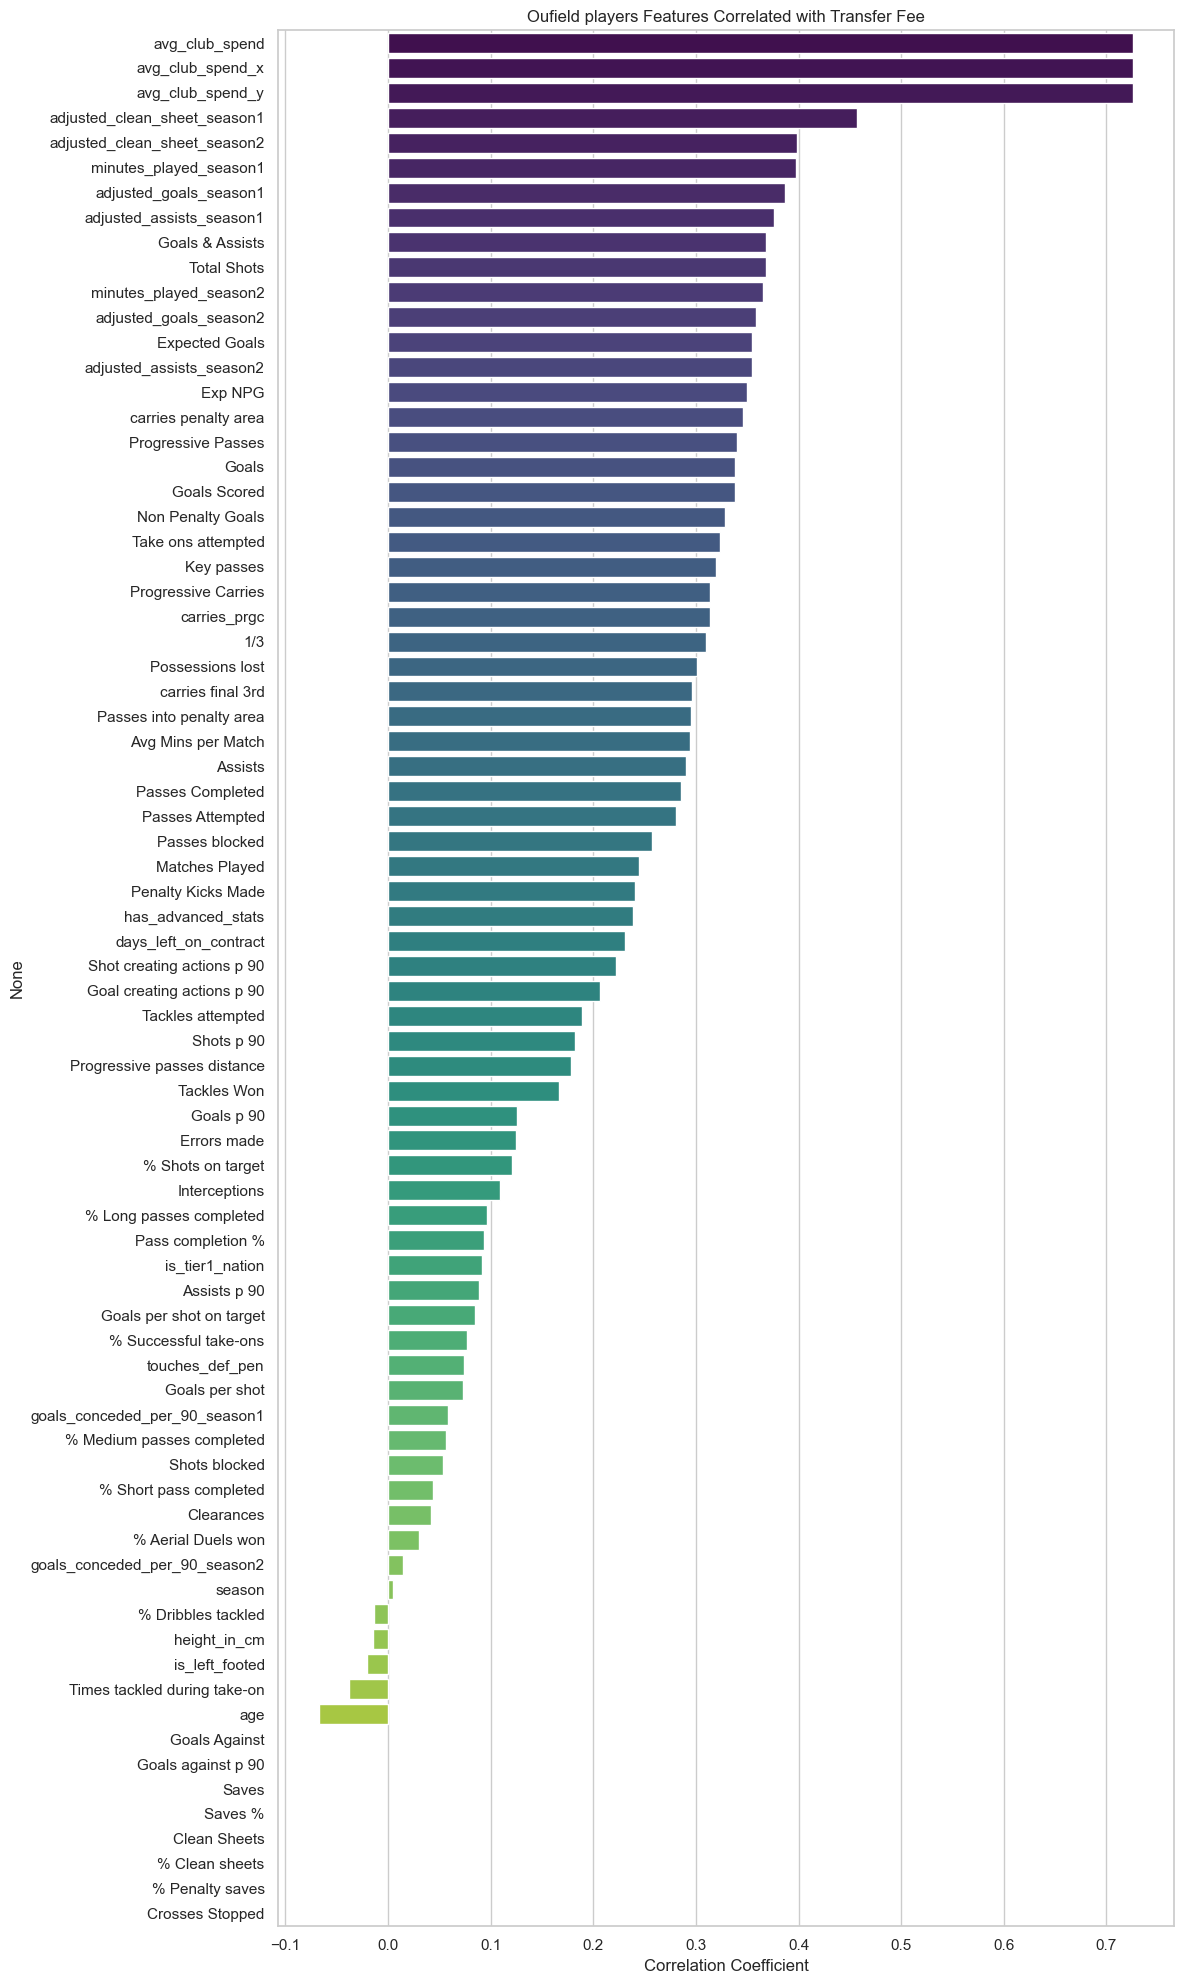

In [45]:
corr_with_target = outfield_numeric_df.corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(12, 20)) 
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')
plt.title('Oufield players Features Correlated with Transfer Fee')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

C:\Users\44757\AppData\Local\Temp\ipykernel_8128\2046223526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')


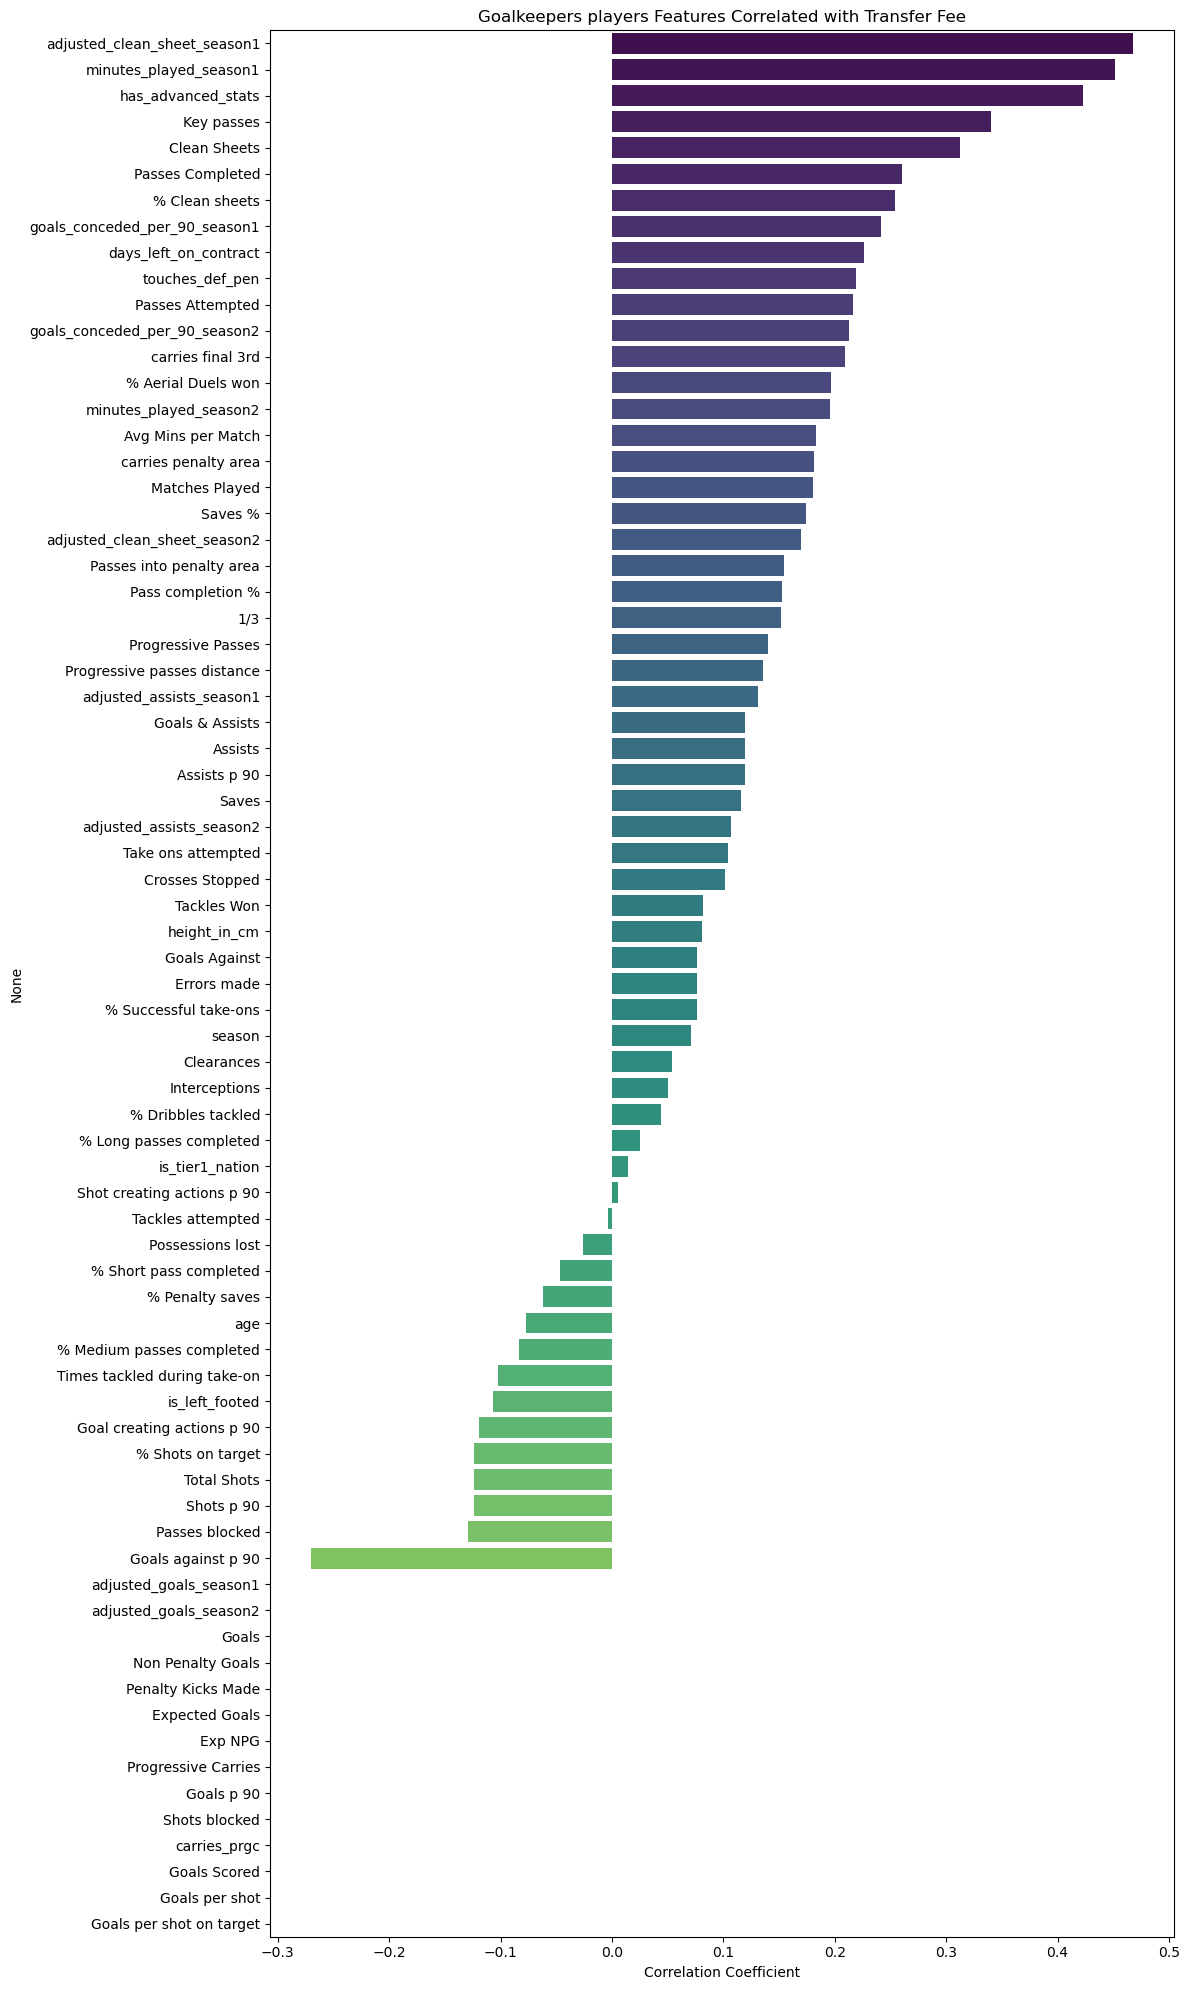

In [9]:
corr_with_target = goalkeeper_numeric_df.corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(12, 20)) 
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')
plt.title('Goalkeepers players Features Correlated with Transfer Fee')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

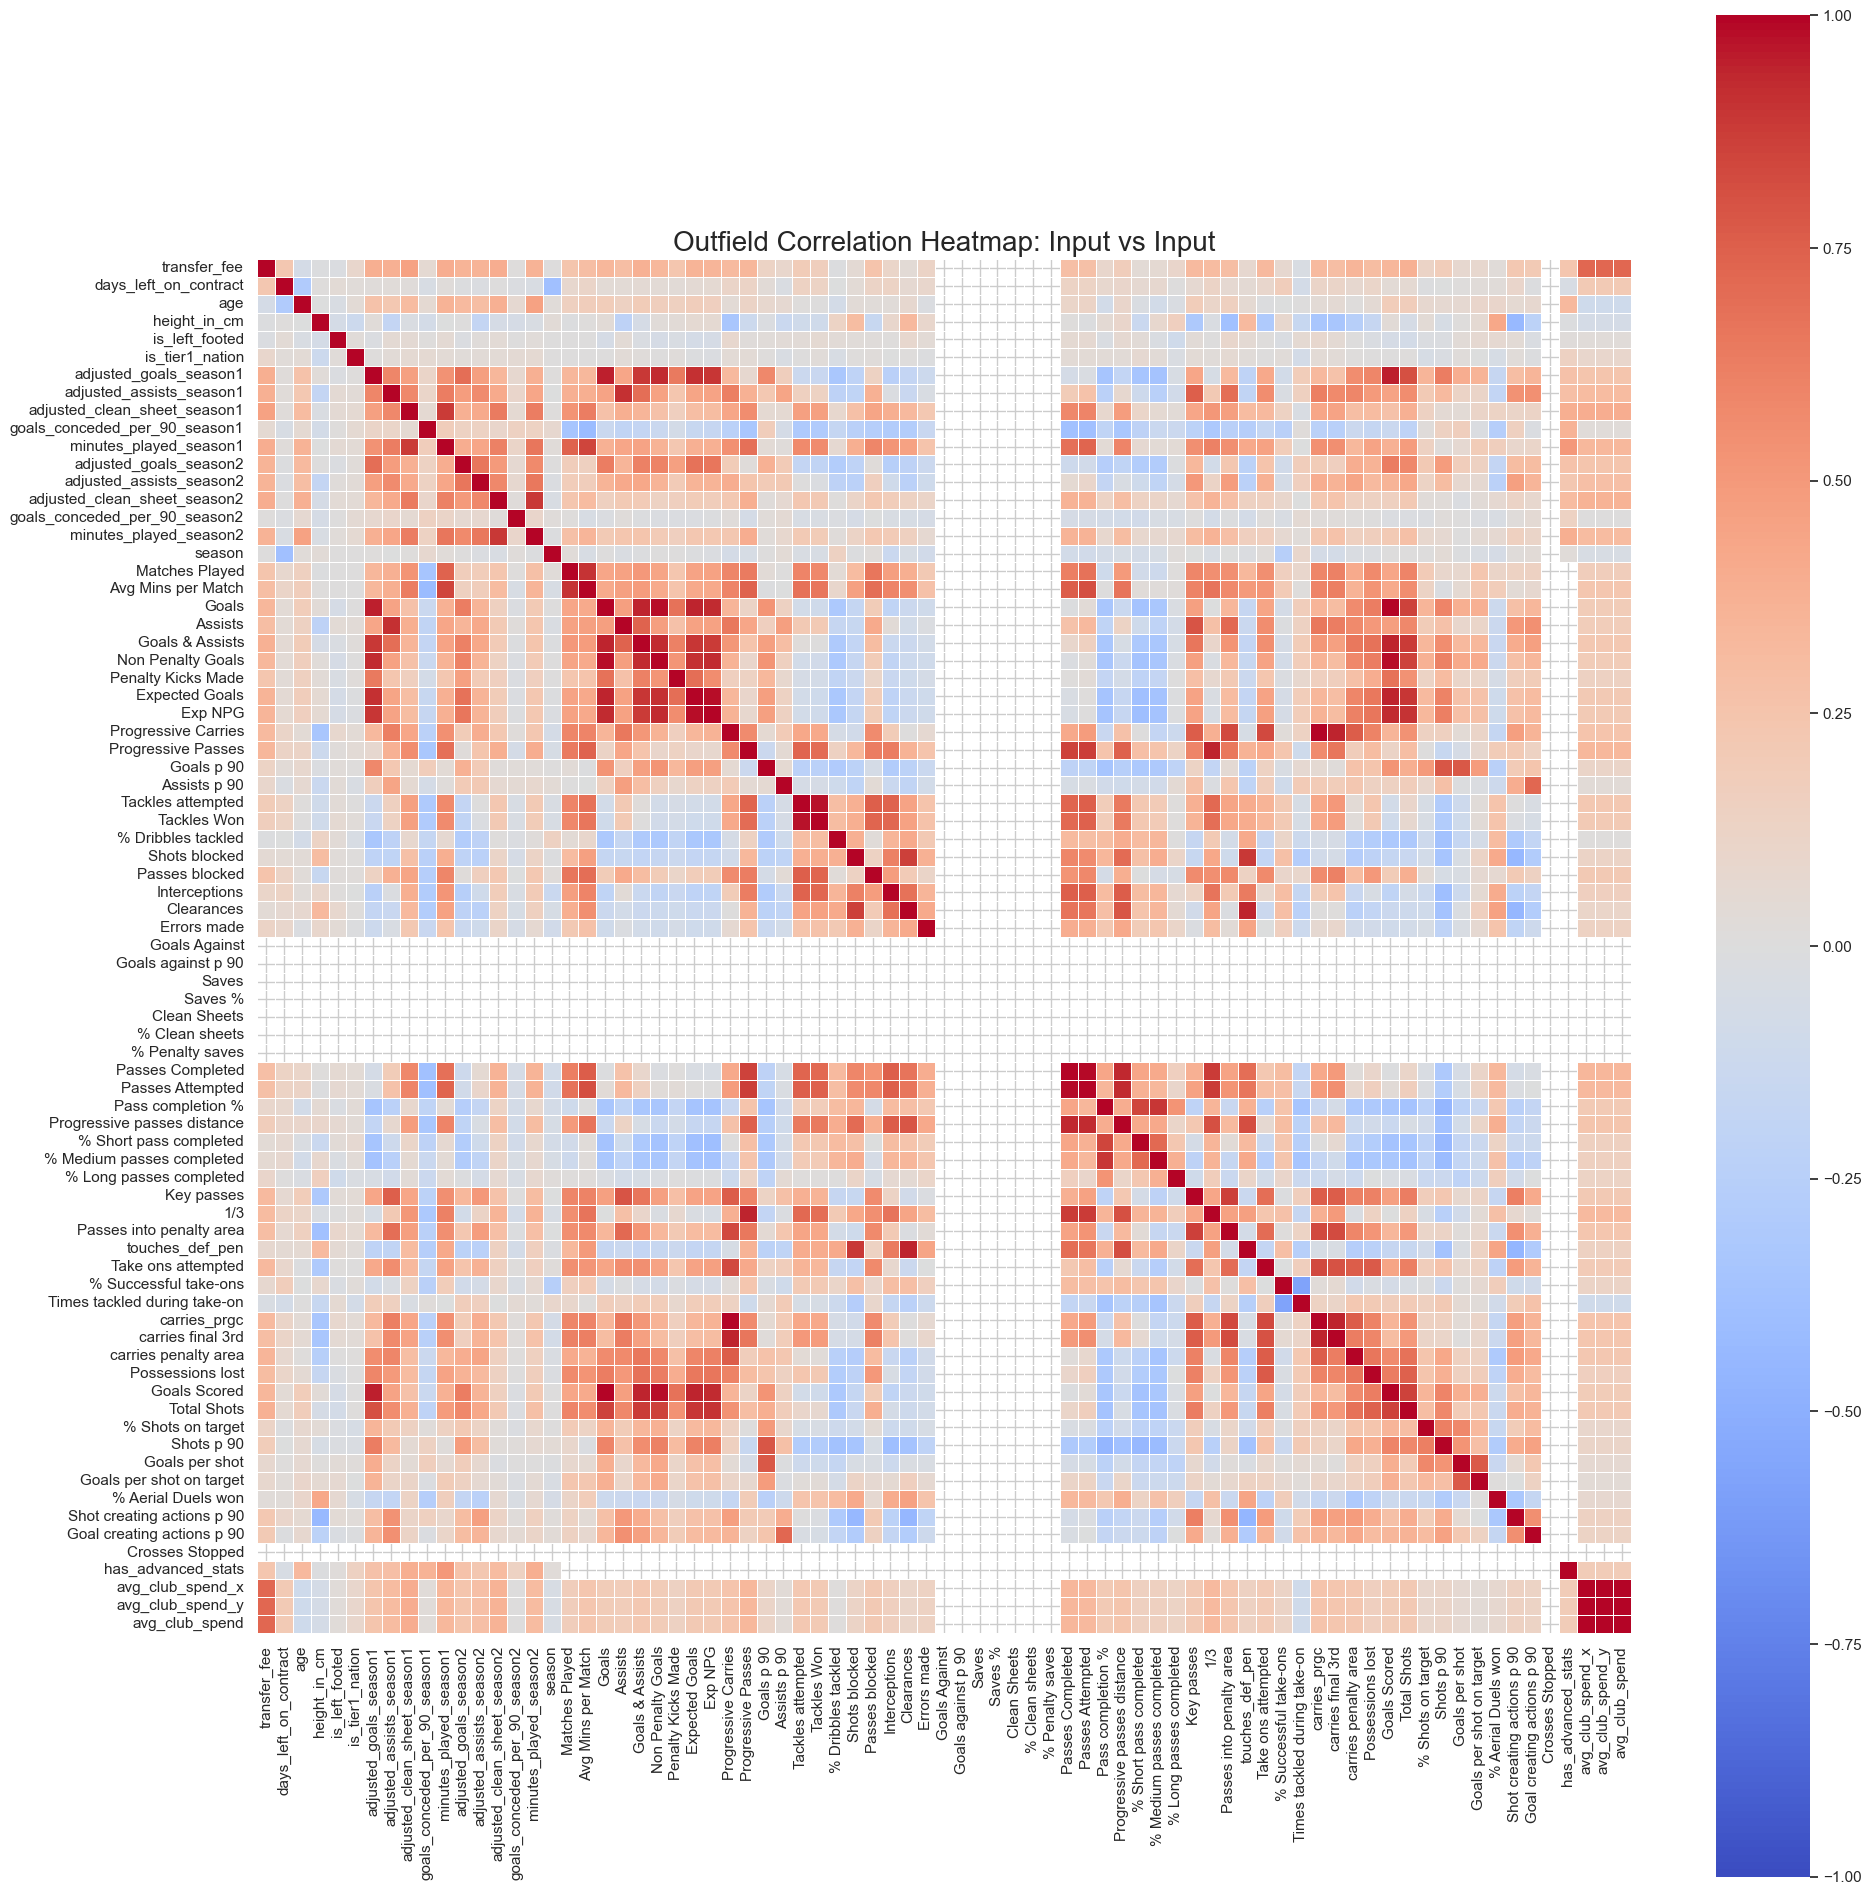

In [ ]:
outfield_corr_matrix = outfield_numeric_df.corr()

plt.figure(figsize=(20,20)) 
sns.heatmap(outfield_corr_matrix, 
            cmap='coolwarm', 
            vmin=-1, vmagevfee=1, 
            square=True, 
            linewidths=0.5)

plt.title('Outfield Correlation Heatmap: Input vs Input', fontsize=20)
plt.tight_layout()
plt.show()

#make the grid into a list of pairs
corr_pairs = outfield_corr_matrix.unstack().reset_index()

# Rename the columns so they are easy to read
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove pairs comparing a feature to itself (like Age vs Age)
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]

# Remove duplicates (so we don't see "Age vs Height" and then "Height vs Age" again)
corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]

# Drop any empty/missing values
corr_pairs = corr_pairs.dropna()

# Create a temporary column to find the highest relationships 
# Use .abs() (absolute value) so strong negative numbers (-0.90) jump to the top alongside strong positives (0.90)
corr_pairs['Absolute_Correlation'] = corr_pairs['Correlation'].abs()

# Sort the list from highest to lowest based on that strength, then delete the temporary column
corr_pairs = corr_pairs.sort_values(by='Absolute_Correlation', ascending=False).drop(columns=['Absolute_Correlation'])

# Round to 2 decimal places and save
corr_pairs['Correlation'] = corr_pairs['Correlation'].round(2)
corr_pairs.to_csv('outfield_pairwise_correlations.csv', index=False)



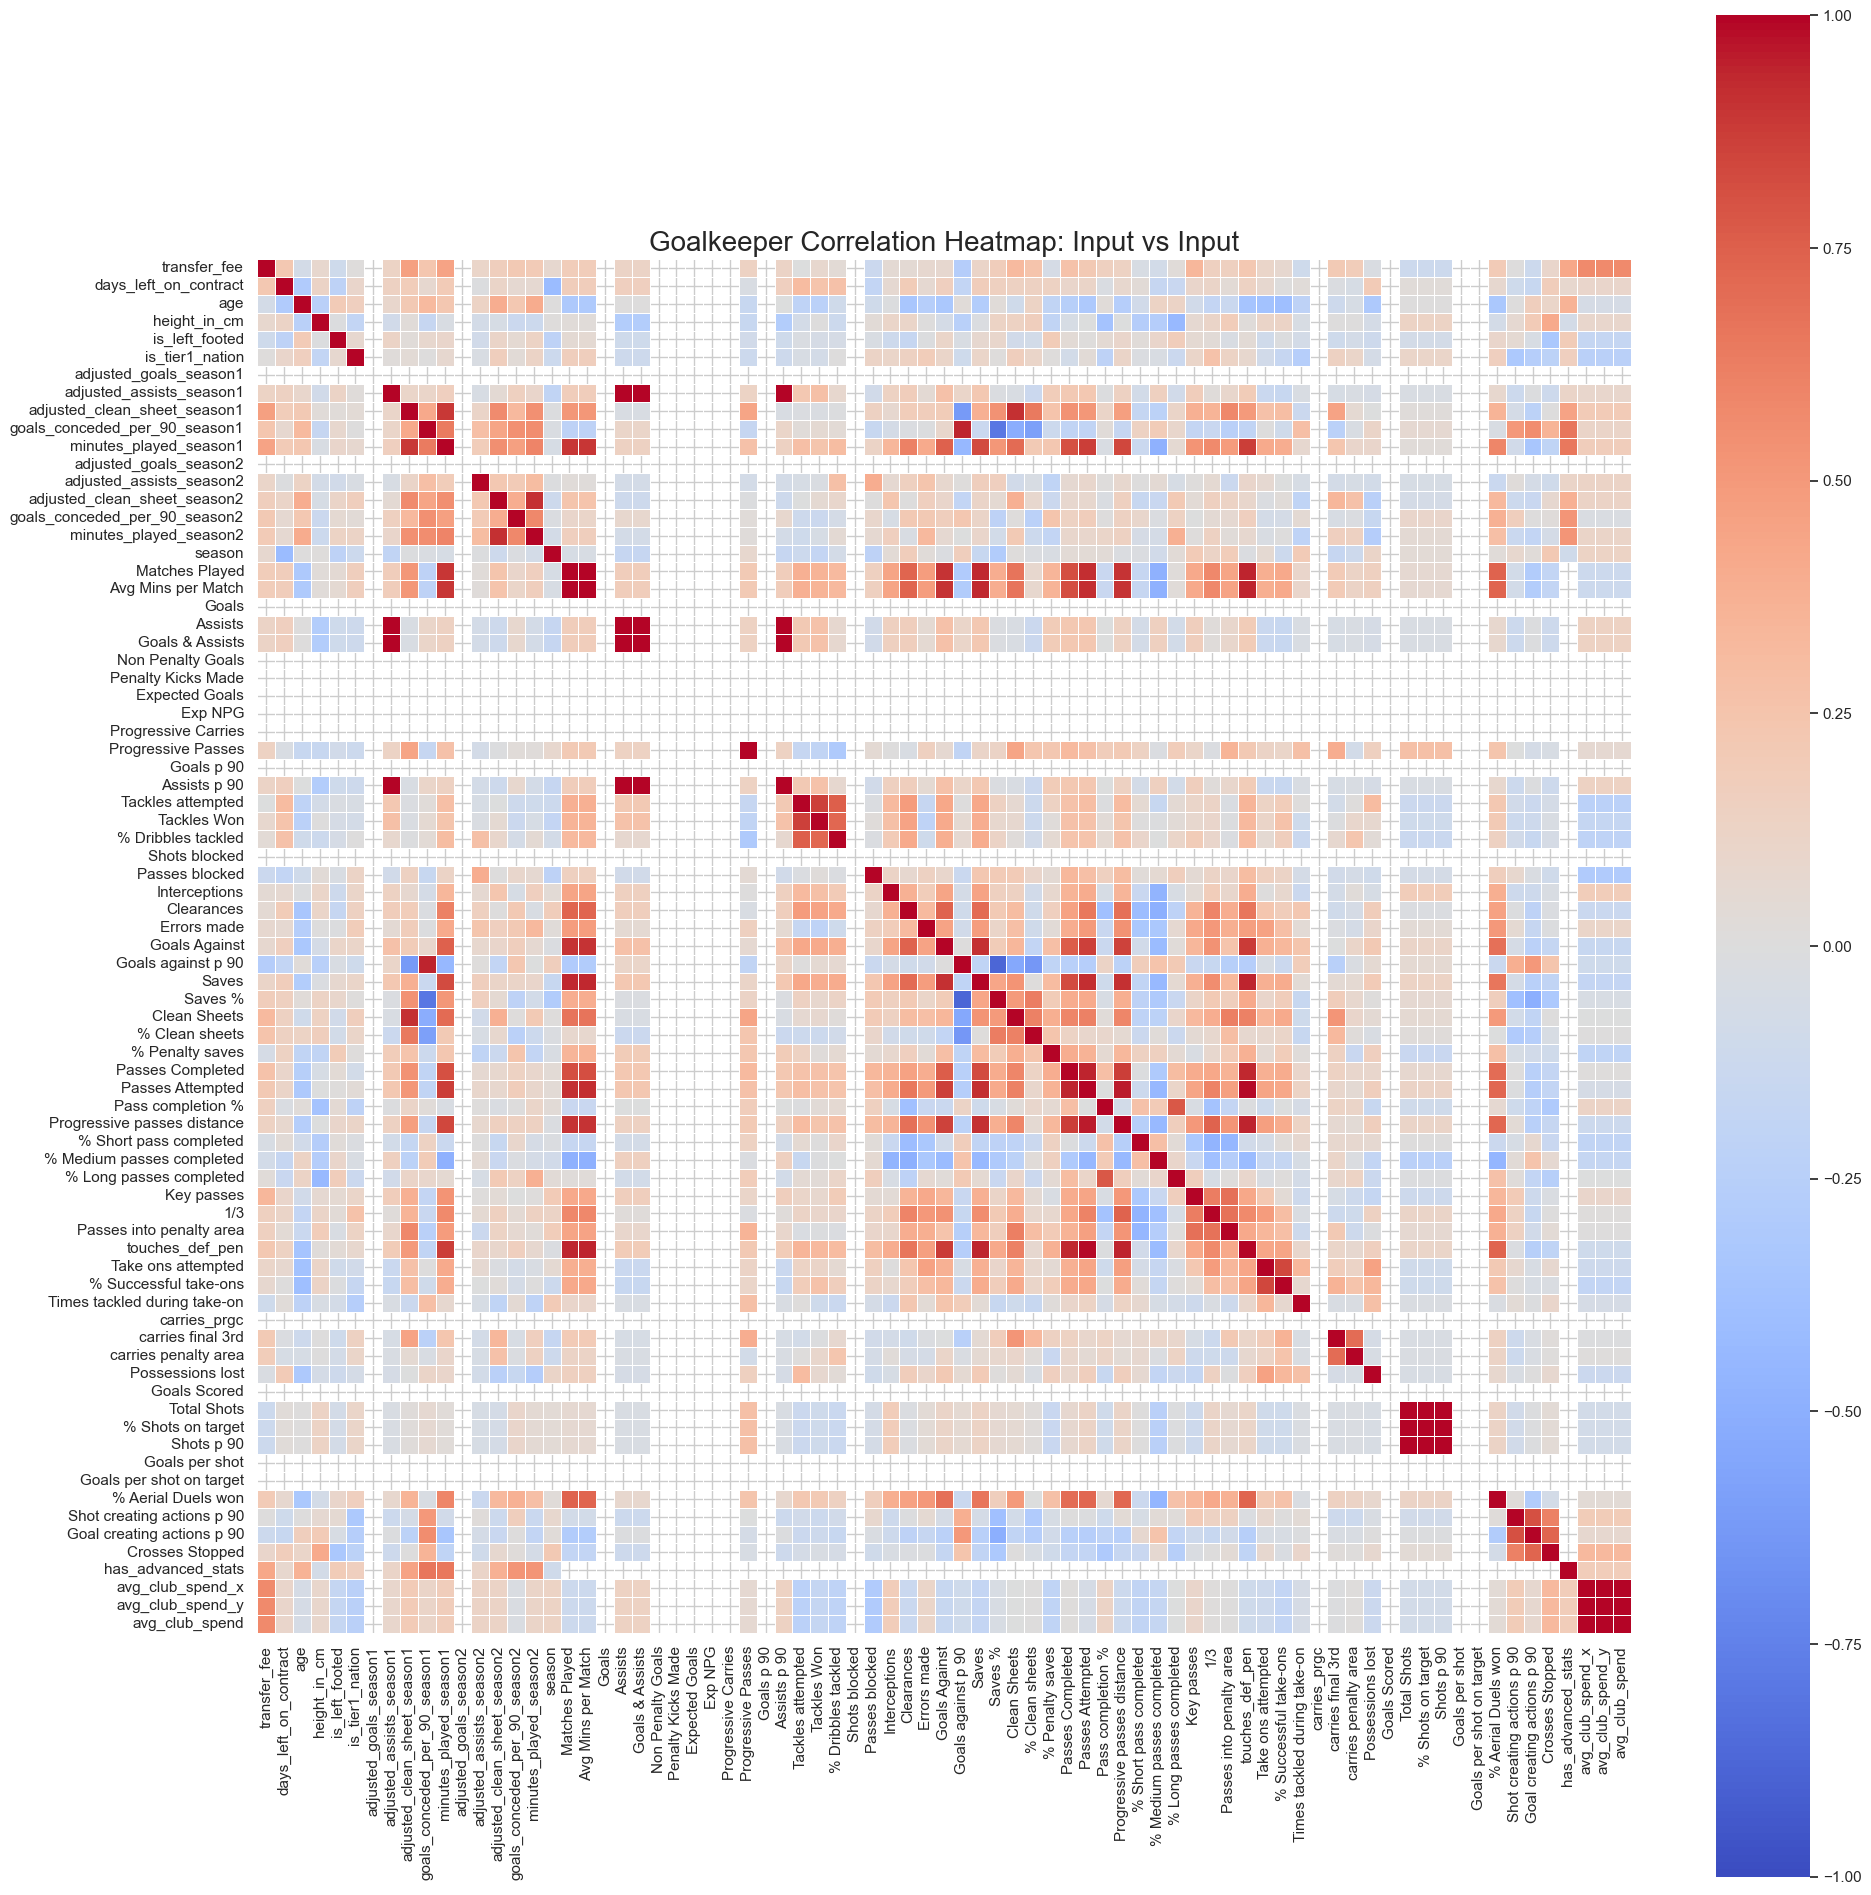

In [ ]:
gk_corr_matrix = goalkeeper_numeric_df.corr()


plt.figure(figsize=(20,20)) 
sns.heatmap(gk_corr_matrix, 
            cmap='coolwarm', 
            vmin=-1, vmagevfee=1, 
            square=True, 
            linewidths=0.5)

plt.title('Goalkeeper Correlation Heatmap: Input vs Input', fontsize=20)
plt.tight_layout()
plt.show()
# save as a csv file
# Take the  grid and make it into a long list of pairs
corr_pairs = gk_corr_matrix.unstack().reset_index()

# Rename the columns 
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove pairs comparing a feature to itselff
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]

#  Remove duplicates (so we don't see "Age vs Height" and then "Height vs Age" again)

corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]

#  Drop any empty/missing values 
corr_pairs = corr_pairs.dropna()

# Create a temporary column to find the highest relationships 
#  use .abs() (absolute value) so strong negative numbers (-0.90) jump to the top alongside strong positives (0.90)
corr_pairs['Absolute_Correlation'] = corr_pairs['Correlation'].abs()

#  Sort the list from highest to lowest based on that strength, then delete the temporary column
corr_pairs = corr_pairs.sort_values(by='Absolute_Correlation', ascending=False).drop(columns=['Absolute_Correlation'])

# Round to 2 decimal places and save
corr_pairs['Correlation'] = corr_pairs['Correlation'].round(2)
corr_pairs.to_csv('gk_pairwise_correlations.csv', index=False)

